In [1]:
%matplotlib inline

In [2]:
# Instalamos las librerías necesarias para ejecutar el notebook del proyecto
%pip install --no-cache-dir -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Aprendizaje Profundo para el Análisis de Imágenes
### Grados en Ingeniería de Telecomunicación
### Curso 2025/2026

# PROYECTO 1:
# Evaluación del impacto de desastres naturales sobre zonas urbanas
# utilizando DNNs para la clasificación de imágenes satelitales

<center><img src='https://www.uc3m.es/ss/Satellite?blobcol=urldata&blobkey=id&blobtable=MungoBlobs&blobwhere=1371614316787&ssbinary=true' width=400 /></center>

## Introducción


En este proyecto vamos a implementar redes neuronales profundas (DNNs) de clasificación para la evaluación del impacto de desastres naturales sobre zonas urbanas, utilizando imágenes satelitales.

## Parte 0: El problema

El objetivo de este trabajo es desarrollar un modelo basado en redes neuronales profundas para la evaluación automática de daños en edificios provocados por desastres naturales. La respuesta ante desastres requiere una comprensión rápida y precisa de las infraestructuras afectadas para optimizar la ayuda humanitaria y las tareas de rescate. Tradicionalmente, estas evaluaciones se realizan de forma presencial o manual, lo cual es peligroso, consume mucho tiempo y retrasa la asistencia crítica.

En este proyecto, utilizaremos técnicas de visión artificial para analizar imágenes de satélite post-evento. El sistema debe ser capaz de clasificar los edificios en dichas imágenes atendiendo al nivel de daño observado en una escala ordinal de cuatro categorías principales:

- Sin daños (No Damage - 0): Edificios intactos, sin signos visibles de daños estructurales, en el tejado o marcas de quemaduras.
- Daño menor (Minor Damage - 1): Edificios parcialmente quemados, rodeados de agua, con elementos del tejado ausentes o grietas visibles.
- Daño mayor (Major Damage - 2): Colapso parcial de paredes o tejados, o estructuras seriamente comprometidas por factores ambientales (como flujo volcánico o inundaciones).
- Destruido (Destroyed - 3): Estructuras calcinadas, completamente colapsadas o que ya no están presentes tras el desastre.

La base de datos que se utilizará para realizar el proyecto se presenta en este artículo:

Gupta, R., Hosfelt, R., Sajeev, S., Patel, N., Goodman, B., Doshi, J., Heim, E., Choset, H., & Gaston, M. (2019). xBD: A Dataset for Assessing Building Damage from Satellite Imagery. arXiv preprint arXiv:1911.09296.

Podéis encontrar más información y acceder al desafío asociado en el siguiente enlace: https://www.xview2.org/

### Detalles de la Base de Datos

xBD es uno de los conjuntos de datos de evaluación de daños en edificios más grandes hasta la fecha. Contiene imágenes de alta resolución (menos de 0.8m de GSD) que cubren 19 desastres naturales diferentes en todo el mundo, incluyendo terremotos, inundaciones, incendios forestales, huracanes y tsunamis.

- Número total de anotaciones de edificios: 850,736.
- Superficie total cubierta: 45,362 $km^2$ de imágenes.
- Estructura del dataset original: Se proporcionan pares de imágenes "antes" y "después" del desastre, junto con polígonos que delimitan la huella de cada edificio.

El dataset se divide originalmente en tres conjuntos: 1) Entrenamiento (Train): 18,336 imágenes con 632,228 polígonos anotados; 2) Validación (Holdout): 1,866 imágenes con 108,784 polígonos; y 3) Test: 1,866 imágenes con 109,724 polígonos (reservado para la evaluación final).

Para la realización del proyecto, se proporciona un archivo .zip que contiene un subconjunto de imágenes de la base de datos, así como ficheros .json con los ids y las etiquetas para las imágenes de los conjuntos de entrenamiento, validación y test. Cada una de las imágenes proporcionadas, de tamaño 1024x1024 píxeles, contiene varios edicicios (más de 150) a ser clasificados. A continuación, se proporciona una clase Dataset que permite dividir las imágenes originales en subimágenes más pequeñas (de tamaño 64x64, dado el parámetro ``patch_size=64``; **no modifique este parámetro para la realización del proyecto**), cada una de ellas correspondiente a un edificio. Estas subimágenes o imágenes de edificios serán las que se utilizarán para realizar el proyecto.

- Número total de imágenes de edificios en el conjunto de entrenamiento: 61171
- Número total de imágenes de edificios en el conjunto de validación: 8495
- Número total de imágenes de edificios en el conjunto de test: 22222

Para cada conjunto (entrenamiento, validación, test) se proporcionan ficheros .json con los siguientes campos para cada muestra (imagen de edificio):
- El ID numérico de la imagen original, que permite construir las rutas (paths) a las imágenes.
- La etiqueta de la imagen de edificio, disponible únicamente para imágenes de entrenamiento y validación (el conjunto de test se reserva para la evaluación del proyecto), siendo esta etiqueta un número entero entre 0 y 3: No Damage - 0; Minor Damage - 1; Major Damage - 2; Destroyed - 3. Para el caso del conjunto de test, las etiquetas no están disponibles (aparecen a -1).

Los estudiantes podrán utilizar los conjuntos de entrenamiento y validación para construir sus soluciones y finalmente proporcionar los scores asociados al conjunto de test. En este notebook se ayudará a construir un sistema básico de referencia. Para ello tenemos que preparar tres procedimientos fundamentales:

1. Procesar una base de datos propia con PyTorch y desarrollar algoritmos que permitan el aumento de datos.
2. Crear una red neuronal feedforward que procese las imágenes y permita evaluar el impacto de desastres naturales sobre los edificios.
3. Realizar fine-tuning sobre una red ya creada y pre-entrenada en bases de datos de gran tamaño y uso general.

## Parte 1: Manejar una base de datos propia con PyTorch. Lectura, preprocesado y aumento de datos.

Vamos a estudiar cómo podemos cargar y preprocesar una base de datos propia en PyTorch. Para ello vamos a usar el paquete ``scikit-image``, que nos permitirá leer las imágenes.

In [4]:
!wget https://www.codabench.org/datasets/download/864def45-a69f-44a6-8c11-4ad6e06d17ea/ -O xBD_UC3M.zip

--2026-04-06 11:05:09--  https://www.codabench.org/datasets/download/864def45-a69f-44a6-8c11-4ad6e06d17ea/
Resolving www.codabench.org (www.codabench.org)... 129.175.8.21
Connecting to www.codabench.org (www.codabench.org)|129.175.8.21|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://miniodis-rproxy.lisn.upsaclay.fr/coda-v2-prod-private/dataset/2026-03-09-1773070083/ef51c51c9133/xBD_UC3M.zip?AWSAccessKeyId=codabench-prod&Signature=cCNmWcMy32iDUJo%2F763gjVD7fOQ%3D&Expires=1775905510 [following]
--2026-04-06 11:05:10--  https://miniodis-rproxy.lisn.upsaclay.fr/coda-v2-prod-private/dataset/2026-03-09-1773070083/ef51c51c9133/xBD_UC3M.zip?AWSAccessKeyId=codabench-prod&Signature=cCNmWcMy32iDUJo%2F763gjVD7fOQ%3D&Expires=1775905510
Resolving miniodis-rproxy.lisn.upsaclay.fr (miniodis-rproxy.lisn.upsaclay.fr)... 129.175.8.29
Connecting to miniodis-rproxy.lisn.upsaclay.fr (miniodis-rproxy.lisn.upsaclay.fr)|129.175.8.29|:443... connected.
HTTP request sent, a

In [5]:
from __future__ import print_function, division
import os
import torch
from skimage import transform, util
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
import random
import numpy.random as npr
import torchvision.transforms.functional as TF
from PIL import Image
from natsort import natsorted
import json
import cv2
import tifffile
from shapely.wkt import loads
from shapely.geometry import Polygon
from tqdm import tqdm

random.seed(42)
npr.seed(42)
torch.manual_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.ion()   # interactive mode
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


Lo primero que vamos a hacer es descargar y descomprimir la base de datos a un directorio local de trabajo:




In [6]:
#SOLO PARA EJECUTAR EN GOOGLE COLAB. Haga esto una única vez sobre la máquina en la que quiera ejecutar su código y luego puede comentar el código
#from shutil import copyfile
#from google.colab import drive
#import os, sys
#drive.mount('/content/drive',force_remount=True)
#Nos situamos en la carpeta en la que vamos a trabajar, modificar línea si es necesario
#copyfile('/content/drive/MyDrive/Path/to/project/folder/xBD_UC3M.zip', './xBD_UC3M.zip') #Copy db files to our working folder

In [7]:
#NOTA: Haga esto una única vez sobre la máquina en la que quiera ejecutar su codigo y luego puede comentar el código
import zipfile
zipPath='./xBD_UC3M.zip' #ponemos el path al fichero zip
extract_path='./data'
with zipfile.ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
import os

# Especifica el directorio donde están las imágenes
directorio = "./data/xBD_UC3M"

### Clase Dataset

La clase ``torch.utils.data.Dataset`` es una clase abstracta que representa un dataset.

Para crear nuestro propio dataset en PyTorch debemos heredar de dicha clase y sobreescribir los siguientes métodos:

-  ``__init__`` el método constructor, encargado de leer e indexar la base de datos.
-  ``__len__`` el método que permite invocar ``len(dataset)``, que nos devuelve el tamaño del dataset.
-  ``__getitem__`` para soportar el indexado ``dataset[i]`` al referirnos a la muestra $i$.

Vamos a crear los datasets de train y test de nuestro problema de evaluación de impactos de desastres naturales. Vamos a leer el csv en el método de inicialización ``__init__``, pero dejaremos la lectura explícita de las imágenes para el método
``__getitem__``. Esta aproximación es más eficiente en memoria porque todas las imágenes no se cargan en memoria al principio, sino que se van leyendo individualmente cuando es necesario.

Cada muestra de nuestro dataset (cuando invoquemos dataset[i]) va a ser un diccionario.

Por otro lado, al definir el dataset, el constructor podrá también tomar un argumento opcional ``transform`` para que podamos añadir pre-procesado y técnicas de data augmentation que le aplicaremos a las imágenes cuando las solicitemos.

In [9]:
class xBDDataset(Dataset):
    def __init__(self, data_dir, split=['train'], patch_size=64, transform=None, max_size=0):
        self.data_dir = data_dir
        self.split = split
        self.patch_size = patch_size
        self.transform = transform
        self.max_size = max_size

        self.image_pre_files = []
        self.image_post_files = []
        self.label_pre_files = []
        self.label_post_files = []
        for s in split:
            disaster_dirs = os.listdir(os.path.join(data_dir, s))

            for d in disaster_dirs:
                image_files = os.listdir(os.path.join(data_dir, s, d, 'images'))
                labels_files = os.listdir(os.path.join(data_dir, s, d, 'labels'))
                self.image_pre_files.append(natsorted([os.path.join(data_dir, s, d, 'images', f) \
                                        for f in image_files if 'pre' in f]))
                self.image_post_files.append(natsorted([os.path.join(data_dir, s, d, 'images', f) \
                                        for f in image_files if 'post' in f]))
                self.label_pre_files.append(natsorted([os.path.join(data_dir, s, d, 'labels', f) \
                                        for f in labels_files if 'pre' in f]))
                self.label_post_files.append(natsorted([os.path.join(data_dir, s, d, 'labels', f) \
                                        for f in labels_files if 'post' in f]))
        self.image_pre_files = natsorted(np.hstack(self.image_pre_files))
        self.image_post_files = natsorted(np.hstack(self.image_post_files))
        self.label_pre_files = natsorted(np.hstack(self.label_pre_files))
        self.label_post_files = natsorted(np.hstack(self.label_post_files))

        print(split)
        self.damage_classes = {
            'no-damage': 0,
            'minor-damage': 1,
            'major-damage': 2,
            'destroyed': 3
        }

        self.patches = []
        self.patch_labels = []
        self._get_patches_data()
        self._print_class_distribution()

    def _process_image(self, idx):
        image_pre = tifffile.imread(self.patch_image_pre[idx])
        if image_pre.shape[:2] != (1024, 1024):
            image_pre = cv2.resize(image_pre, (1024, 1024))

        image_post = tifffile.imread(self.patch_image_post[idx])
        if image_post.shape[:2] != (1024, 1024):
            image_post = cv2.resize(image_post, (1024, 1024))

        return image_pre, image_post #, mask_pre

    def _create_mask(self, label_path):
        mask = np.zeros((1024, 1024), dtype=np.uint8)

        try:
            with open(label_path, 'r') as f:
                data = json.load(f)

            if 'features' in data and 'xy' in data['features']:
                features = data['features']['xy']

                for feature in features:
                    if 'wkt' in feature:
                        try:
                            geom = loads(feature['wkt'])
                            if isinstance(geom, Polygon) and geom.is_valid:
                                coords = np.array(geom.exterior.coords, dtype=np.int32)
                                cv2.fillPoly(mask, [coords], 1)
                        except:
                            continue
        except:
            pass

        return mask

    def _get_patches_data(self):
        num_files = len(self.image_pre_files)
        self.patch_pre = []
        self.patch_post = []
        self.label_pre = []
        self.label_post = []
        self.label_post_path = []
        self.patch_image_pre = []
        self.patch_image_post = []

        for n in np.arange(num_files):
            label_pre_path = self.label_pre_files[n]
            label_post_path = self.label_post_files[n]

            with open(label_pre_path, 'r') as f_pre, open(label_post_path, 'r') as f_post:
                data_pre = json.load(f_pre)
                data_post = json.load(f_post)

                if 'features' in data_post and 'xy' in data_post['features']:
                    features_post = data_post['features']['xy']

                    for feature in features_post:
                        if 'wkt' in feature and 'properties' in feature:
                            props = feature['properties']
                            if props.get('feature_type') == 'building':
                                damage_type = props.get('subtype', 'no-damage')

                                if damage_type in self.damage_classes or damage_type == -1:
                                    self.patch_pre.append(feature['wkt'])
                                    self.patch_post.append(feature['wkt'])
                                    self.label_pre.append(0) # No damage before the event
                                    self.label_post.append(self.damage_classes[damage_type] if damage_type in self.damage_classes else -1)
                                    self.label_post_path.append(label_post_path)
                                    self.patch_image_pre.append(self.image_pre_files[n])
                                    self.patch_image_post.append(self.image_post_files[n])

        if self.max_size > 0:
            new_dataset_size = self.max_size
            idx = np.random.RandomState(seed=42).permutation(range(len(self.patch_pre)))
            self.patch_pre = np.array(self.patch_pre)[idx[0:new_dataset_size]]
            self.patch_post = np.array(self.patch_post)[idx[0:new_dataset_size]]
            self.label_pre = np.array(self.label_pre)[idx[0:new_dataset_size]]
            self.label_post = np.array(self.label_post)[idx[0:new_dataset_size]]
            self.label_post_path = np.array(self.label_post_path)[idx[0:new_dataset_size]]
            self.patch_image_pre = np.array(self.patch_image_pre)[idx[0:new_dataset_size]]
            self.patch_image_post = np.array(self.patch_image_post)[idx[0:new_dataset_size]]

    def _extract_patch(self, image, mask, wkt_str):
        geom = loads(wkt_str)
        if isinstance(geom, Polygon) and geom.is_valid:
            coords = np.array(geom.exterior.coords, dtype=np.int32)

            x_min, y_min = coords.min(axis=0)
            x_max, y_max = coords.max(axis=0)

            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2

            half_size = self.patch_size // 2

            x1 = max(0, center_x - half_size)
            y1 = max(0, center_y - half_size)
            x2 = min(image.shape[1], center_x + half_size)
            y2 = min(image.shape[0], center_y + half_size)

            patch = image[y1:y2, x1:x2]
            if mask is not None:
                mask_patch = mask[y1:y2, x1:x2]
            else:
                mask_patch = None

            if patch.shape[0] > 0 and patch.shape[1] > 0:
                patch = cv2.resize(patch, (self.patch_size, self.patch_size))
                if mask_patch is not None:
                    mask_patch = cv2.resize(mask_patch, (self.patch_size, self.patch_size))
        else:
            patch = np.zeros((self.patch_size, self.patch_size, image.shape[-1]))
            mask_patch = np.zeros((self.patch_size, self.patch_size))
        return patch, mask_patch

    def _print_class_distribution(self):
        class_counts = {}
        for label in self.label_post:
            class_counts[label] = class_counts.get(label, 0) + 1

        if 'test' not in self.split:
            class_names = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
            total_count = []
            for i, name in enumerate(class_names):
                count = class_counts.get(i, 0)
                total_count.append(count)
                print(f'{name}: {count}')
        print('Número total de parches de edificios encontrados: '+str(len(self.label_post)))

    def __len__(self):
        return len(self.patch_post)

    def __getitem__(self, idx):
        # Images (pre-, post-) and mask (pre-)
        # print(self.patch_image_pre[idx])
        image_pre, image_post = self._process_image(idx)
        image_pre = image_pre / 255.0
        image_post = image_post / 255.0

        mask = self._create_mask(self.label_post_path[idx])

        patch_pre, _ = self._extract_patch(image_pre, mask, self.patch_post[idx])
        patch_post, mask_patch = self._extract_patch(image_post, mask, self.patch_post[idx])

        label_pre = self.label_pre[idx]
        label_post = self.label_post[idx]

        sample = {'patch_pre': patch_pre,
                  'patch_post': patch_post,
                  'mask_patch': mask_patch,
                  'label_pre': label_pre,
                  'label_post': label_post,
                  'idx': idx}
        if self.transform:
            #sample = self.transform(sample)
            sample['patch_pre'] = self.transform(sample['patch_pre'])
            sample['patch_post'] = self.transform(sample['patch_post'])
        return sample

### Preparación de la base de datos

La clase `xBDDataset` se encarga de procesar imágenes satelitales emparejadas (antes y después de un desastre natural) y sus correspondientes etiquetas en formato JSON.

En lugar de procesar imágenes enteras de 1024x1024 píxeles, esta clase localiza los polígonos de los edificios y extrae subimágenes (parches) centradas en cada uno de ellos. Esto permite que el modelo se enfoque únicamente en la estructura afectada, clasificando el nivel de daño en cuatro categorías: sin daño, daño menor, daño mayor o destruido.

A continuación, instanciamos el dataset. (Asegúrate de cambiar `data_dir` por la ubicación real de tus datos).

In [10]:
# Instanciamos el dataset (modo evaluación para no aplicar aumentación y ver las imágenes reales)
# Reemplaza 'data_dir' con tu ruta local
patch_size = 64
train_dataset = xBDDataset('data/xBD_UC3M', ['train'], patch_size=patch_size)

['train']
no-damage: 50928
minor-damage: 4659
major-damage: 2357
destroyed: 3227
Número total de parches de edificios encontrados: 61171


Spiegazione del risultato:
nel costruttore __init__ vengono chiamate automaticamente due funzioni:
self._get_patches_data()
self._print_class_distribution().
La seconda (_print_class_distribution) stampa quante volte compare ogni classe di danno nel dataset di trainin

Antes de recortar los parches, es útil ver cómo lucen las imágenes originales completas (pre y post-desastre). La clase tiene una función interna `_process_image(idx)` que lee los archivos .tif, de tamaño 1024x1024.

Vamos a extraer un índice aleatorio y visualizar el panorama general del área afectada.

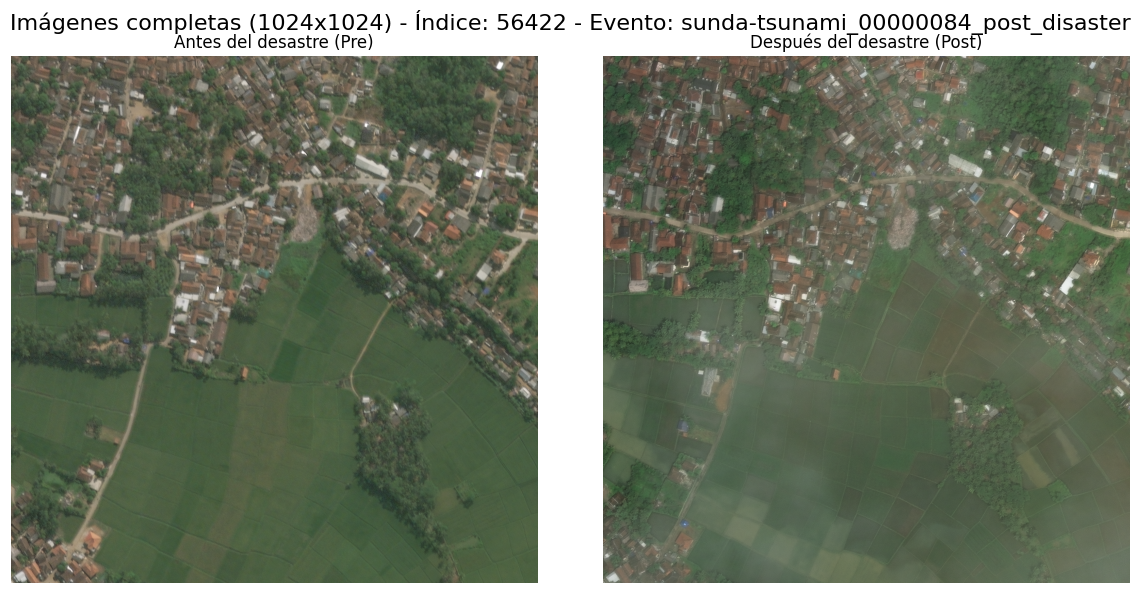

In [11]:
# Elegimos un índice aleatorio
idx = np.random.randint(0, len(train_dataset))

# Obtenemos las imágenes completas originales usando la función interna
image_pre_full, image_post_full = train_dataset._process_image(idx)
event = train_dataset.label_post_path[idx].split('/')[-1][:-5]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Imágenes completas (1024x1024) - Índice: {idx} - Evento: {event}", fontsize=16)

axes[0].imshow(image_pre_full)
axes[0].set_title("Antes del desastre (Pre)")
axes[0].axis('off')

axes[1].imshow(image_post_full)
axes[1].set_title("Después del desastre (Post)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

La función principal de este Dataset es su método __getitem__. Para un índice dado, no devuelve la imagen completa, sino un parche de tamaño `64 x 64` (definido en `patch_size`) centrado en un edificio específico.

La función devuelve un diccionario, que contiene las siguientes variables:

- 'patch_pre': Imagen de edificio pre-desastre (no se usará en este proyecto).
- 'patch_post': Imagen de edificio post-desastre.
- 'mask_patch': Máscara binaria para la imagen de edificio (no se usará en esta proyecto).
- 'label_pre': Etiqueta de la imagen de edificio pre-desastre (siempre No Damage - 0, no se usará en este proyecto).
- 'label_post': Etiqueta de la imagen de edificio post-desastre (0-3, indicando la severidad)
- 'idx': ID del edificio en el conjunto de entrenamiento/validación/test.

Vamos a visualizar qué es exactamente lo que la red neuronal podría ver durante el entrenamiento. Para este proyecto, por simplicidad, únicamente trabajaremos con el patch post-desastre `patch_post` y su etiqueta correspondiente `label_post`.

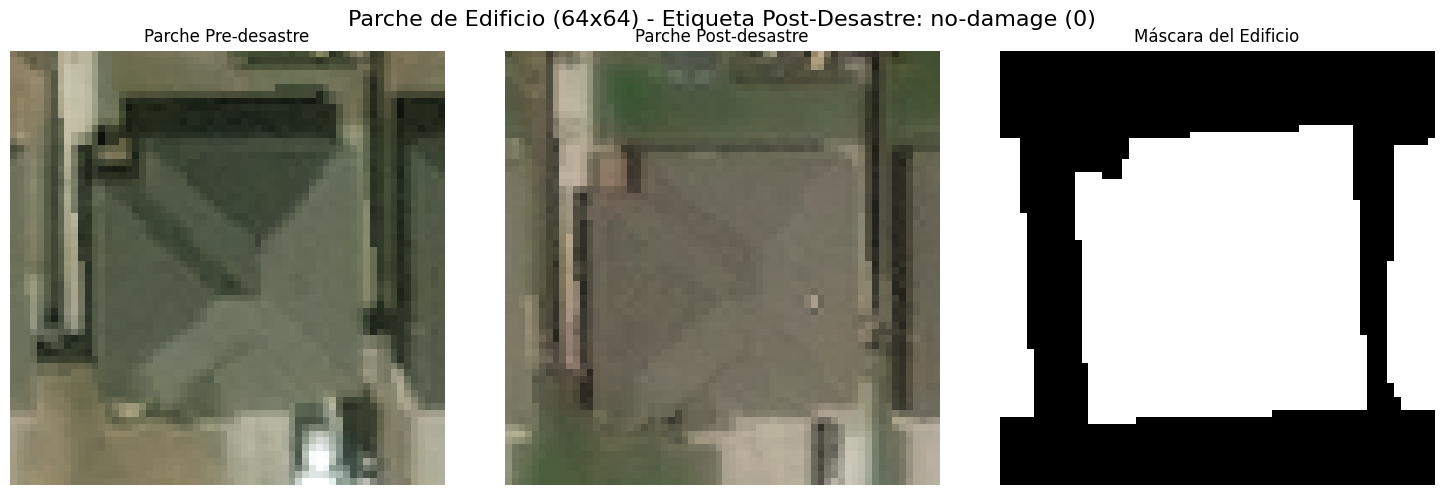

In [12]:
# Elegimos un índice aleatorio
idx = np.random.randint(0, len(train_dataset))

# Obtenemos un ejemplo procesado directamente desde el método __getitem__
sample = train_dataset[idx]

patch_pre = sample['patch_pre']
patch_post = sample['patch_post']
mask_patch = sample['mask_patch']
label_post = sample['label_post']

# Mapeo inverso de las clases de daño para la visualización
inverse_damage_classes = {v: k for k, v in train_dataset.damage_classes.items()}
damage_text = inverse_damage_classes[label_post]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Parche de Edificio (64x64) - Etiqueta Post-Desastre: {damage_text} ({label_post})", fontsize=16)

# Aseguramos que los valores estén en el rango correcto para matplotlib (0-255 o 0-1)
axes[0].imshow(patch_pre)
axes[0].set_title("Parche Pre-desastre")
axes[0].axis('off')

axes[1].imshow(patch_post)
axes[1].set_title("Parche Post-desastre")
axes[1].axis('off')

axes[2].imshow(mask_patch, cmap='gray')
axes[2].set_title("Máscara del Edificio")
axes[2].axis('off')

plt.tight_layout()
plt.show()

**IMPORTANTE**: El parámetro opcional ``max_size`` en el constructor permite submuestrear el número de imágenes y reducir así el tamaño del dataset. Si este argumento no se especifica o se sitúa ``max_size=0``, entonces el dataset incluye todas las imágenes disponibles. Este parámetro es **útil para entrenar usando bases de datos más pequeñas durante la validación de hiperparámetros y la toma de decisiones** en el proceso de diseño de la solución. Trabajar con menos imágenes reduce considerablemente el tiempo de entrenamiento, si bien puede llevar a resultados y conclusiones que no correlen perfectamente con lo que ocurriría si se usase el conjunto de entrenamiento al completo. Lógicamente, cuanto mayor es el conjunto de datos de entrenamiento, más estables serán los resultados y las decisiones, a costa de un mayor tiempo de entrenamiento. Por tanto, queda a discrección del alumno situar este parámetro al valor que considere oportuno.


### Preprocesado de datos y data augmentation: Transformaciones

En esta sección vamos a aplicar técnicas de aumento de datos para generar nuevas imágenes de entrada a la red, derivadas de las del conjunto de entrenamiento, que puedan permitir mejorar su capacidad de generalización y evitar, por tanto, el sobreajuste. Estas transformaciones se aplicarán únicamente durante la etapa de entrenamiento.

En primer lugar, vamos a crear algo de código de pre-procesado. En particular vamos a crear 5 transformaciones:

-  ``RandomCrop``: para recortar parches en la imagen de forma aleatoria, de un tamaño determinado, lo que nos permite hacer data augmentation (**solo en train**).
-  ``CenterCrop``: para recortar el centro de la imagen con el tamaño indicado (**útil para test, donde no tiene sentido hacer un único crop aleatorio**).
-  ``Rescale``: para escalar la imagen al tamaño necesario por la red (ej. 64x64 píxeles).
-  ``ToTensor``: para convertir las matrices numpy en tensores torch (reordenando los ejes) y alimentar a la red.
- ``Normalize ``: para hacer un escalado estándar de los valores de los píxeles, restándoles la media y dividiéndolos por su desviación típica, de forma independiente para cada componente de color RGB.

Las vamos a escribir como clases llamables en vez de simples funciones para que no necesitemos pasar los parámetros de la transformación cada vez que las llamemos. Para ello, solo tenemos que implementar el método ``__call__`` y, si fuese necesario, el método ``__init__``.
Luego podremos usar una transformación con el siguiente código:

    tsfm = Transform(params)
    transformed_sample = tsfm(sample)


In [13]:
class RandomCrop(object):
    """Recortamos aleatoriamente la imagen.

    Args:
        output_size (tupla o int): Tamaño del recorte. Si int, recorte cuadrado

    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def __call__(self, sample):
        image = sample['patch_post']

        h, w = image.shape[:2]
        new_h, new_w = self.output_size

        if h>new_h:
            top = np.random.randint(0, h - new_h)
        else:
            top=0

        if w>new_w:
            left = np.random.randint(0, w - new_w)
        else:
            left = 0

        image = image[top: top + new_h,
                     left: left + new_w]

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample


class CenterCrop(object):
    """Crop the central area of the image

    Args:
        output_size (tupla or int): Crop size. If int, square crop

    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def __call__(self, sample):
        image = sample['patch_post']
        h, w = image.shape[:2]
        new_h, new_w = self.output_size
        rem_h = h - new_h
        rem_w = w - new_w

        if h>new_h:
            top = int(rem_h/2)
        else:
            top=0

        if w>new_w:
            left = int(rem_w/2)
        else:
            left = 0

        image = image[top: top + new_h,
                     left: left + new_w]

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample


class Rescale(object):
    """Re-escalamos la imagen a un tamaño determinado.

    Args:
        output_size (tupla o int): El tamaño deseado. Si es una tupla, output es el output_size.
        Si es un int, la dimensión más pequeña será el output_size
            y mantendremos la relación de aspecto original.
    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        self.output_size = output_size

    def __call__(self, sample):
        image = sample['patch_post']

        h, w = image.shape[:2]
        if isinstance(self.output_size, int):
            if h > w:
                new_h, new_w = self.output_size * h / w, self.output_size
            else:
                new_h, new_w = self.output_size, self.output_size * w / h
        else:
            new_h, new_w = self.output_size

        new_h, new_w = int(new_h), int(new_w)

        img = transform.resize(image, (new_h, new_w))

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample


class ToTensor(object):
    """Convertimos ndarrays de la muestra en tensores."""

    def __call__(self, sample):
        image, label = sample['patch_post'], sample['label_post']

        # Cambiamos los ejes
        # numpy image: H x W x C
        # torch image: C X H X W
        image = image.transpose((2, 0, 1))
        image = torch.from_numpy(image.astype(np.float32))

        label=torch.tensor(label,dtype=torch.long)

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': label,
                  'idx': sample['idx']}
        return sample


class Normalize(object):
    """Normalizamos los datos restando la media y dividiendo por las desviaciones típicas.

    Args:
        mean_vec: El vector con las medias.
        std_vec: el vector con las desviaciones típicas.
    """

    def __init__(self, mean,std):

        assert len(mean)==len(std),'Length of mean and std vectors is not the same'
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image = sample['patch_post']
        c, h, w = image.shape
        assert c==len(self.mean), 'Length of mean and image is not the same'
        dtype = image.dtype
        mean = torch.as_tensor(self.mean, dtype=dtype, device=image.device)
        std = torch.as_tensor(self.std, dtype=dtype, device=image.device)
        image.sub_(mean[:, None, None]).div_(std[:, None, None])

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample

#### Ejercicio

Utilice el código siguiente para aplicar transformaciones a las imágenes. Experimente con los valores de los parámetros de las transformaciones. Lea la documentación de cada clase para ver su sintaxis y entender cómo cambiarlos.

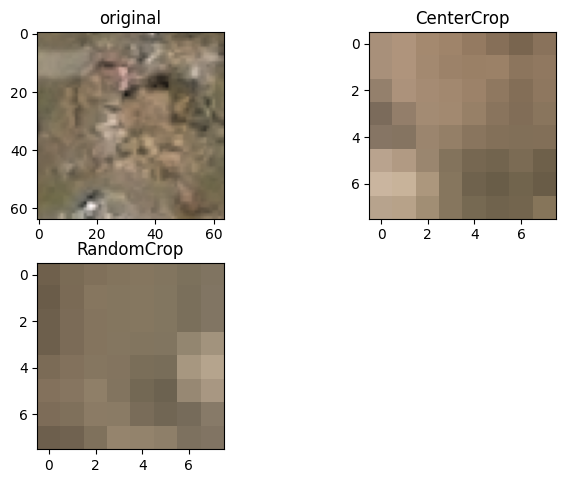

In [14]:
### Modify this code to make your experiments....
rcrop = RandomCrop(8)
ccrop = CenterCrop(8)

# Apply each of the above transforms on sample.
fig = plt.figure(figsize=(7,7))
n = 100
sample = train_dataset[n]
ax = plt.subplot(3,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['patch_post'])

for i, tsfrm in enumerate([ccrop, rcrop]):
    transformed_sample = tsfrm(sample)

    ax = plt.subplot(3, 2, i+2)
    plt.tight_layout()
    ax.set_title(type(tsfrm).__name__)
    plt.imshow(transformed_sample['patch_post'])

plt.show()

### El paquete torchvision.transforms

El paquete ``torchvision.trasforms`` incorpora múltiples métodos que implementan transformaciones útiles para el preprocesado de imágenes y, en especial, el aumento de datos. Estas transformaciones se pueden aplicar sobre tensores torch (``torch.tensor``) o bien sobre imágenes. Sin embargo, torchvision usa la librería PIL para leer y procesar imágenes, y no scikit-image, que es la que estamos empleando nosotros en el notebook. Además, la aplicación de algunas transformaciones a nuestras imágenes no es directa, ya que deberían aplicarse tanto a la imagen del lunar como a la máscara binaria de segmentación. En consecuencia, para usar una transformación de ``torchvision.transforms`` necesitaremos implementar un código que haga los siguientes pasos:

- 1) Convierta las imágenes scikit-image, que son matrices de numpy, a imágenes tipo PILImage
- 2) Aplique la transformación desde la librería ``torchvision.transforms``
- 3) Convierta de vuelta la imagen PILImage a scikit-image.

Y también necesitamos aplicar las transformaciones tanto a la imagen como a la máscara piel-lesión, si fuese necesario. A continuación se propone una clase ``TVCenterCrop``, que implementa la misma funcionalidad que la previa ``CenterCrop``, pero usando el método correspondiente en torchvision. Este ejemplo se proporcionar como guía para que el alumno pueda incorporar a su solución otras transformaciones de ``torchvision.transforms``.


In [15]:
class TVCenterCrop(object):
    """Crop the central area of the image. Example using the method in torchvision. Requires to
    internally convert from skimage (numpy array) to PIL Image

    Args:
        output_size (tupla or int): Crop size. If int, square crop

    """

    def __init__(self, size):
        self.CC=transforms.CenterCrop(size)

    def __call__(self, sample):
        image = sample['patch_post']
        pil_image=Image.fromarray(util.img_as_ubyte(image))
        pil_image=self.CC(pil_image)
        image = util.img_as_float(np.asarray(pil_image))

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample

Ahora aplicamos la transformación para comprobar el resultado:

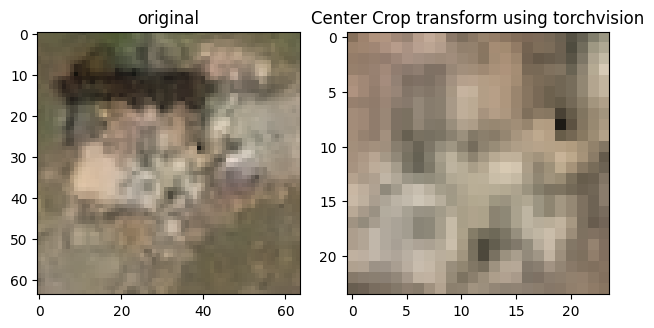

In [16]:
# Apply each of the above transforms on sample.
fig = plt.figure()
sample = train_dataset[65]
ax = plt.subplot(1,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['patch_post'])

tvcc=TVCenterCrop(24)

transformed_sample = tvcc(sample)
ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Center Crop transform using torchvision')
plt.imshow(transformed_sample['patch_post'])

plt.show()

#### Ejercicio

Implemente otras transformaciones que crea que puedan ser útiles para esta base de datos, ya sea utilizando métodos de ``scikit-image`` o que ya vengan incluidos en ``torchvision.transforms``.


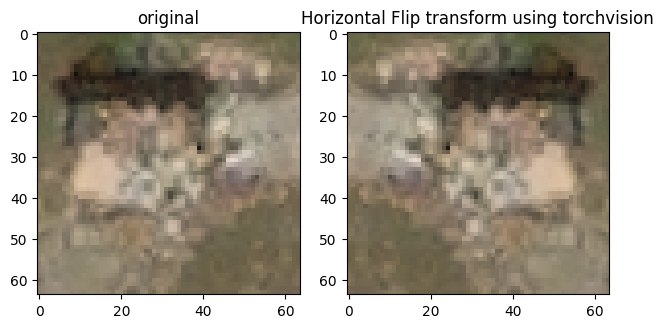

In [17]:
class TVRandomHorizontalFlip(object):

    def __init__(self, p):
        self.flip = transforms.RandomHorizontalFlip(p)

    def __call__(self, sample):
        image = sample['patch_post']

        # numpy → PIL
        pil_image = Image.fromarray(util.img_as_ubyte(image))

        # apply flip
        pil_image = self.flip(pil_image)

        # PIL → numpy
        image = util.img_as_float(np.asarray(pil_image))

        sample = {'patch_pre': sample['patch_pre'],
                  'patch_post': image,
                  'mask_patch': sample['mask_patch'],
                  'label_pre': sample['label_pre'],
                  'label_post': sample['label_post'],
                  'idx': sample['idx']}
        return sample

        # Apply each of the above transforms on sample.
fig = plt.figure()
sample = train_dataset[65]
ax = plt.subplot(1,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['patch_post'])

tvcc=TVRandomHorizontalFlip(1)

transformed_sample = tvcc(sample)
ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Horizontal Flip transform using torchvision')
plt.imshow(transformed_sample['patch_post'])

plt.show()

### Transformaciones compuestas

En el siguiente ejemplo vamos a meter transformaciones aleatorias sobre características fotométricas (ColorJitter) y flips verticales y horizontales con probabilidad 0.5. Tenga en cuenta que las transformaciones son aleatorias, por lo que cada vez que leemos una imagen de la base de datos, se le aplica una transformación diferente. Esto nos lleva a tener una base de datos de tamaño infinito (lógicamente con la limitación de que todas las imágenes se generan a partir de las originales, que son limitadas). Los parámetros que pasamos en los constructores de las transformaciones definen la aleatoriedad de las transformaciones (rangos, probabilidades, etc.).


#### Ejercicio

Utilice el código siguiente para aplicar transformaciones compuestas a las imágenes. Haga algunas pruebas con diferentes composiciones. Experimente también cómo afecta el orden de las mismas al pasárselas al método Compose()

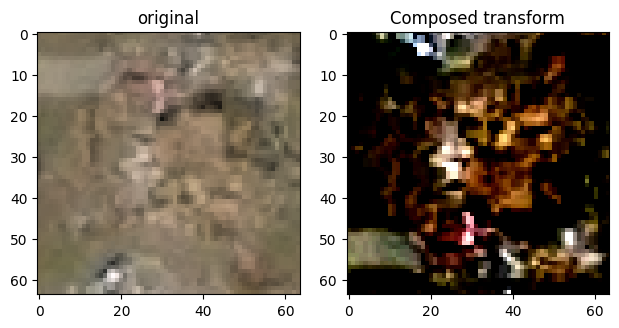

In [18]:
#Pixel means and stds expected by models in torchvision
pixel_mean=[0.485, 0.456, 0.406]
pixel_std=[0.229, 0.224, 0.225]

composed = transforms.Compose(
     [transforms.ColorJitter(brightness = 0.05, contrast = 0.05, saturation = 0.05, hue = 0.01),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor(),
     transforms.Normalize(pixel_mean,pixel_std)])

# Apply each of the above transforms on sample.
fig = plt.figure()
n = 100
sample = train_dataset[n]
ax = plt.subplot(1,2, 1)
plt.tight_layout()
ax.set_title('original')
plt.imshow(sample['patch_post'])

pil_sample=Image.fromarray(util.img_as_ubyte(sample['patch_post']))
transformed_sample = composed(pil_sample)
ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Composed transform')
plt.imshow(transformed_sample.permute(1,2,0))

plt.show()

#### Ejercicio

Utilice el código de la celda anterior para probar diferentes combinaciones de transformaciones y discuta los resultados. Tenga en cuenta que el orden de las transformaciones es importante e influye en los resultados.

#### Ejercicio

Las técnicas de aumento de datos son útiles para modelar de forma aleatoria transformaciones que puedan ocurrir en el escenario de la aplicación y que, por tanto, son susceptibles de aparecer en imágenes de test. Por tanto, la selección de las técnicas/transformaciones a aplicar es dependiente del problema y varía de una base de datos a otra. Por tanto, estudie las imágenes de la base de datos y trate de pensar qué transformaciones pueden ser de utilidad para mejorar las prestaciones de una red de evaluación de impactos de desastres naturales.

**Transformaciones** **útiles**


*   **RandomHorizontalFlip y RandomVerticalFlip**: Una fotografía
satelital puede tomarse en cualquier orientación — un edificio dañado visto desde el norte o desde el sur es el mismo edificio. No hay pérdida de sentido físico.
*  **RandomRotation (ej. 90°, 180°, 270°)** por el mismo motivo, las imágenes satelitales no tienen un "arriba" natural como las fotos normales. Rotar 90° produce una imagen perfectamente plausible.
* **ColorJitter con valores moderados**: las condiciones de iluminación, la hora del día, la estación del año y el sensor satelital utilizado varían de una imagen a otra. Pequeñas variaciones de brillo y contraste son realistas. Sin embargo, hay que tener cuidado de no exagerar: el color de los escombros y los restos tiene significado visual para la red.
* **RandomCrop seguido de Resize**: se puede hacer un recorte ligeramente más pequeño (ej. 56x56) y redimensionar a 64x64. Esto simula pequeñas variaciones en la posición del edificio dentro del parche.


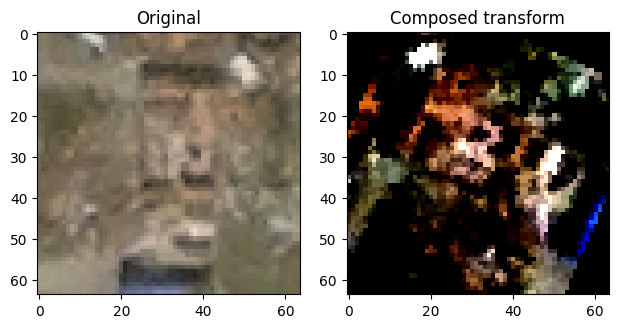

In [19]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std  = [0.229, 0.224, 0.225]

# Transformaciones compuestas para imágenes satelitales de desastres naturales
composed = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.RandomApply([transforms.RandomCrop(56), transforms.Resize((64,64))], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.03, contrast=0.03,
                           saturation=0.03, hue=0.01)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(pixel_mean, pixel_std)
])

# Visualización
fig = plt.figure()
n = 50
sample = train_dataset[n]

ax = plt.subplot(1, 2, 1)
plt.tight_layout()
ax.set_title('Original')
plt.imshow(sample['patch_post'])

pil_sample = Image.fromarray(util.img_as_ubyte(sample['patch_post']))
transformed_sample = composed(pil_sample)

ax = plt.subplot(1, 2, 2)
plt.tight_layout()
ax.set_title('Composed transform')
plt.imshow(transformed_sample.permute(1, 2, 0))
plt.show()





Iterando el dataset
-----------------------------

Ahora vamos a poner todo en común para crear los datasets de train y test con las transformaciones correspondientes.
En resumen, cada vez que muestreemos alguna imagen del dataset (de train):
- Leeremos la imagen
- Aplicaremos las transformaciones y recortaremos la imagen
- Como el cropping final es aleatorio, estaremos aplicando data augmentation durante el muestreo

Podemos iterar de manera sencilla sobre el dataset con un bucle ``for i in range``.




In [20]:
#Datos de train
train_dataset = xBDDataset('data/xBD_UC3M', ['train'], patch_size=64,
                                    max_size=500, ### IMPORTANTE: Ponemos max_size=500 para limitar el
                                                  ### tamaño del dataset a 500 imágenes y limitar así el tiempo de entrenamiento
                                                  ### Ponga el valor a 0 para entrenar el modelo final

                                    transform=transforms.Compose([
                                    transforms.ToPILImage(),
                                    transforms.RandomHorizontalFlip(p=0.5),
                                    transforms.RandomVerticalFlip(p=0.5),
                                    transforms.RandomRotation(degrees=90),
                                    transforms.RandomApply([transforms.RandomCrop(56), transforms.Resize((64,64))], p=0.5),
                                    transforms.RandomApply([transforms.ColorJitter(brightness=0.03, contrast=0.03,
                                                          saturation=0.03, hue=0.01)], p=0.5),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
                                    ]))
#Datos de test
val_dataset = xBDDataset('data/xBD_UC3M', ['val'], patch_size=64,
                                    transform=transforms.Compose([
                                    transforms.ToPILImage(),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
                                    ]))

#Datos de test
test_dataset = xBDDataset('data/xBD_UC3M', ['test'], patch_size=64,
                                    transform=transforms.Compose([
                                    transforms.ToPILImage(),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
                                    ]))

for i in range(len(train_dataset)):
    sample = train_dataset[i]

    print(i, sample['patch_post'].size(), sample['label_post'])

    if i == 3:
        break

['train']
no-damage: 4189
minor-damage: 368
major-damage: 195
destroyed: 248
Número total de parches de edificios encontrados: 5000
['val']
no-damage: 6041
minor-damage: 773
major-damage: 1214
destroyed: 467
Número total de parches de edificios encontrados: 8495
['test']
Número total de parches de edificios encontrados: 22222
0 torch.Size([3, 64, 64]) 0
1 torch.Size([3, 64, 64]) 0
2 torch.Size([3, 64, 64]) 0
3 torch.Size([3, 64, 64]) 0


Y por último tenemos que crear un DataLoader que nos permita:

-  Muestrear batches de muestras para pasárselos a la red durante el entrenamiento
-  Desordenar los datos
-  Cargar los datos en paralelo usando múltiples cores.

``torch.utils.data.DataLoader`` es un iterador que proporciona todas estas características. Un parámetro importante del iterador es ``collate_fn``. Podemos especificar cómo se organizan las muestras en batches eligiendo la función más adecuada. En cualquier caso, la opción por defecto debería funcionar bien en la mayoría de los casos.




0 torch.Size([64, 3, 64, 64]) tensor([0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 2, 2, 0, 0, 1, 2, 0, 1,
        1, 0, 0, 2, 2, 0, 3, 0, 3, 2, 2, 3, 0, 3, 3, 2, 1, 2, 2, 0, 3, 2, 3, 0,
        2, 0, 1, 1, 1, 1, 3, 2, 1, 2, 3, 0, 1, 0, 2, 2])


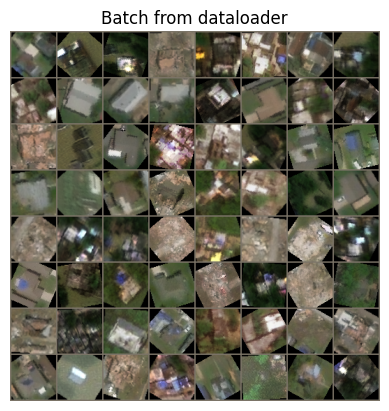

1 torch.Size([64, 3, 64, 64]) tensor([2, 1, 3, 0, 2, 2, 0, 1, 0, 1, 1, 0, 1, 0, 0, 3, 3, 1, 0, 3, 1, 1, 2, 1,
        1, 0, 1, 2, 3, 2, 1, 0, 3, 0, 2, 1, 1, 1, 2, 3, 0, 1, 3, 2, 0, 0, 1, 2,
        1, 3, 0, 2, 1, 0, 1, 1, 3, 1, 0, 2, 2, 1, 1, 0])


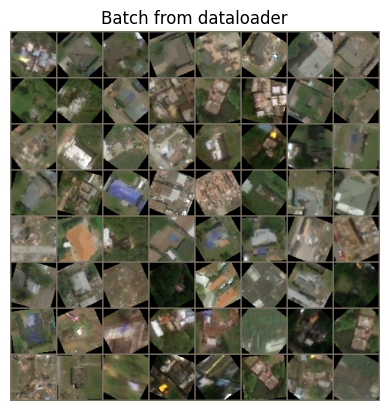

2 torch.Size([64, 3, 64, 64]) tensor([0, 2, 3, 2, 3, 0, 0, 3, 3, 0, 2, 1, 0, 3, 3, 2, 1, 0, 2, 2, 0, 2, 2, 0,
        3, 0, 3, 2, 0, 0, 2, 3, 2, 0, 2, 1, 3, 1, 2, 1, 2, 2, 2, 0, 2, 3, 0, 0,
        1, 3, 3, 2, 1, 2, 0, 2, 2, 0, 0, 1, 0, 2, 3, 3])


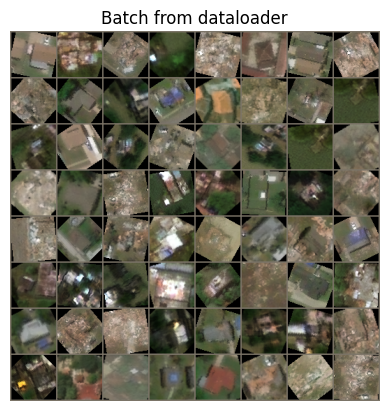

3 torch.Size([64, 3, 64, 64]) tensor([2, 0, 3, 2, 2, 0, 3, 0, 0, 3, 1, 0, 3, 1, 3, 0, 1, 3, 0, 3, 3, 1, 2, 0,
        0, 1, 3, 1, 0, 1, 0, 3, 1, 2, 2, 3, 1, 0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 0,
        2, 1, 2, 2, 2, 2, 0, 1, 0, 3, 2, 2, 2, 0, 1, 0])


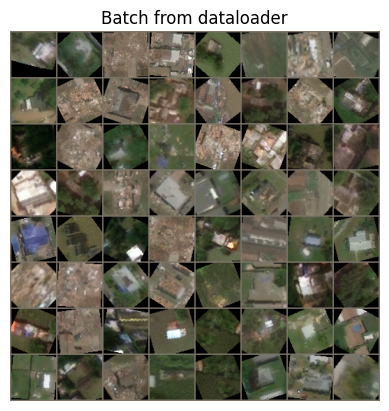

In [21]:
from torch.utils.data import WeightedRandomSampler

# Pesi per bilanciare le classi sbilanciate
class_counts = torch.tensor([50928, 4659, 2357, 3227], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

sample_weights = torch.tensor(
    [class_weights[label].item() for label in train_dataset.label_post]
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# shuffle=True rimosso, sostituito da sampler=sampler
train_dataloader = DataLoader(train_dataset, batch_size=64,
                        sampler=sampler, num_workers=3)

#Dataset de validación => No desordenamos
#Como no hay que hacer backward, podemos aumentar mucho el batch_size
val_dataloader = DataLoader(val_dataset, batch_size=128,
                        shuffle=False, num_workers=3)
#Dataset de test => No desordenamos
test_dataloader = DataLoader(test_dataset, batch_size=128,
                        shuffle=False, num_workers=3)


# Función auxiliar para visualizar un batch de datos
def show_batch(sample_batched):
    """Mostramos las imágenes de un batch."""
    images_batch, labels_batch = \
            sample_batched['patch_post'], sample_batched['label_post']
    batch_size = len(images_batch)
    im_size = images_batch.size(2)
    grid_border_size = 2

    #Generamos el grid
    grid = utils.make_grid(images_batch)
    #Lo pasamos a numpy y lo desnormalizamos
    grid=grid.numpy().transpose((1, 2, 0))
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    grid = std * grid + mean
    grid = np.clip(grid, 0, 1)
    plt.imshow(grid)
    plt.title('Batch from dataloader')

for i_batch, sample_batched in enumerate(train_dataloader):
    print(i_batch, sample_batched['patch_post'].size(),
          sample_batched['label_post'])

    plt.figure()
    show_batch(sample_batched)
    plt.axis('off')
    plt.ioff()
    plt.show()

    #Mostramos datos de los 4 primeros batches y paramos.
    if i_batch == 3:
        break

## Parte 2: Crear y entrenar una red de evaluación de impactos de desastres naturales

En la segunda parte del notebook vamos a crear una red de evaluación de impactos de desastres naturales desde cero. Para ello, las imágenes pueden tener el tamaño que uno desee (siempre haciendo la red adecuada para ese tamaño), aunque recomendamos que utilicen tamaños estándar para la clasificación de imágenes como 64x64 píxeles.

En la siguiente celda se proporciona el esqueleto de la red llamada CustomNet, con los métodos necesarios: ` __init__` (el constructor) y ``forward`` (el método forward, que procesa una imagen y proporciona el vector con los scores de las 4 clases).

In [22]:
"""class CustomNet(nn.Module):
    def __init__(self):
        # En el inicializador vamos a especificar los bloques de cómputo que tienen parámetros a definir
        # OJO: los definimos de forma independiente => De momento son bloques aislados y no forman una red
        super(CustomNet, self).__init__()

        #Añadir el código aquí******

         # Capa convolucional:
        # canales in = 3 (la imagen de entrada tiene 3 canales RGB)
        # 6 canales out
        # filtro de tamaño 5x5
        self.conv1 = nn.Conv2d(3, 6, 5)
        # Capa de Maxpooling con tamaño 2x2
        self.pool = nn.MaxPool2d(2, 2)
        # Capa convolucional:
        # canales in = 6 (de la capa anterior)
        # 16 canales out
        # filtro de tamaño 5x5
        self.conv2 = nn.Conv2d(6, 16, 5)
        # Mas capas convolucionales aumentando el número de canales y manteniendo filtros de 5x5
        self.conv3 = nn.Conv2d(16, 32, 5, 2)
        # Capa completamente conectada que espera 64 canales y unas dimensiones espaciales de 10x10 (antes del flattening)
        # y produce 120 canales a la salida
        self.fc1 = nn.Linear(32*2*2, 120)
        # Capa completamente conectada que proporciona la salida final (y = Wx + b)
        # canales in = 120 (capa anterior)
        # canales out = 4 (las 4 clases del problema)
        self.fc2 = nn.Linear(120, 4)

    #En forward definimos la red a través de su grafo computacional
    #Es donde conectamos los bloques antes definidos y metemos otros más simples
    def forward(self, x):

        #Bloque de procesado : conv -> relu -> pooling
        x = self.pool(F.relu(self.conv1(x)))
        #Bloque de procesado : conv -> relu -> pooling
        x = self.pool(F.relu(self.conv2(x)))
        #Bloque de procesado : conv -> relu -> pooling
        x = self.pool(F.relu(self.conv3(x)))
        #Transformamos en vector para que entre a capas fully-connected
        x = x.flatten(1)
        #Bloque de procesado: fully-connected -> relu
        x = F.relu(self.fc1(x))
        #Fully-connected final para generar salida
        x = self.fc2(x)
        return x"""
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, out_3x3, out_5x5):
        super(InceptionModule, self).__init__()
        self.branch1 = nn.Conv2d(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Conv2d(in_channels, out_3x3, kernel_size=3, padding=1)
        self.branch3 = nn.Conv2d(in_channels, out_5x5, kernel_size=5, padding=2)
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_1x1, kernel_size=1)
        )

    def forward(self, x):
        b1 = F.relu(self.branch1(x))
        b2 = F.relu(self.branch2(x))
        b3 = F.relu(self.branch3(x))
        b4 = F.relu(self.branch4(x))
        return torch.cat([b1, b2, b3, b4], dim=1)


#CUSTOMNET CON INCEPTION + DROPOUT
class CustomNet(nn.Module):
    def __init__(self):
        super(CustomNet, self).__init__()
        self.conv1     = nn.Conv2d(3, 6, 5)
        self.pool      = nn.MaxPool2d(2, 2)
        self.inception = InceptionModule(in_channels=6,
                                         out_1x1=8,
                                         out_3x3=16,
                                         out_5x5=8)
        self.conv3     = nn.Conv2d(40, 32, 5, stride=2)
        self.dropout   = nn.Dropout(p=0.5)
        self.fc1       = nn.Linear(32 * 3 * 3, 120)
        self.fc2       = nn.Linear(120, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(self.inception(x))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#### Ejercicio

Defina una red que procese un batch de imágenes (por ej. de tamaño 64x64), y obtenga para cada una la salida con los scores de las 4 clases que tenemos en el problema.

**IMPORTANTE**: La estructura de la red debe de ser acorde para lograr transformar el tensor de entrada de cada imagen Nx3x64x64 (N el número de imágenes en el batch, 3 los canales RGB, y 64 las dimensiones espaciales) en el tensor con los scores de cada caso de tamaño Nx4 (N el número de imágenes del batch y las 4 clases del problema). Para ello, tiene que ajustar la arquitectura, incluyendo el número de capas, los strides de cada una, etc. de modo que consiga transformar el tensor en el vector final. Como ayuda, se proporciona el siguiente código que le permite ejecutar la red sobre un batch de imágenes y ver cuál es la forma de la salida generada.


#### Truco

Comience comentando las líneas del método forward excepto el primer bloque convolucional, ejecute la celda siguiente y entonces verá cuál es la forma de la salida de dicho bloque. A partir de esos datos, podrá poner los parámetros de entrada del siguiente bloque, para que así sean compatibles. Vaya descomentando bloque a bloque para ver de forma secuencial los tamaños de las salidas de cada bloque, y así poder adecuar las dimensiones del bloque siguiente.

In [23]:
customNet = CustomNet() #Invocamos el constructor de la red (método init())
customNet.to(device) #Pasamos la red al device que estemos usando (gpu)
#Obtenemos un batch de datos y extraemos imágenes y etiquetas
data=next(iter(train_dataloader))
inputs = data['patch_post'].to(device).float()
labels = data['label_post'].to(device)

batchSize = labels.shape
print('El tamaño del tensor que representa un batch de imágenes es {}'.format(inputs.shape))

#Lo pasamos por la red
with torch.set_grad_enabled(False):
    outputs = customNet(inputs)
    print('El tamaño del tensor de salida es {}'.format(outputs.shape))

El tamaño del tensor que representa un batch de imágenes es torch.Size([64, 3, 64, 64])
El tamaño del tensor de salida es torch.Size([64, 4])


## Parte 3: Entrenar y evaluar la red

En la tercera parte del notebook vamos a construir un primer sistema automático de evaluación de impactos de desastres naturales basado en la red que hemos creado en la sección anterior. Para entrenar y evaluar la red, necesitamos definir varios elementos, tales como la métrica de rendimiento, la función de pérdida, el optimizador o la estrategia de learning rate. En las próximas secciones iremos configurando estos elementos.

### Métrica de evaluación de rendimiento
Comenzaremos definiendo la métrica que emplearemos para evaluar nuestra red: Macro F1-score (ver https://en.wikipedia.org/wiki/F-score#Macro_F1).

F1-score es una métrica que combina la precisión (precision) y la exhaustividad (recall) en un solo valor, utilizando su media armónica:

<center><img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/ee9b2235daf4402960538e73d6310bc8c2b8de52'  /></center>

donde:

<center><img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/6bf4ff05845a63d65d7a43394f708e0882dba7c1'  /></center>

  (proporción de predicciones positivas que son correctas).

<center><img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/541bb1ab5d962d6dfcbc9298d9c7da2a97133dbe'  /></center>

  (proporción de ejemplos positivos correctamente identificados).

F1-score es útil cuando hay un desbalance entre clases, ya que penaliza los modelos que tienen alta precisión pero bajo recall (o viceversa).

<center><img src='https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/350px-Precisionrecall.svg.png'  /></center>

**Macro-F1 Score**

En problemas de clasificación multiclase, F1-score se calcula para cada clase i (n clases) y luego se promedia de forma equitativa, dando lugar a Macro-F1:

<center><img src='https://framerusercontent.com/images/zwzfzVO8wUp97ay2qxw7rB0w.webp'  width=400/></center>

### Matriz de confusión

También podemos sacar más conclusiones si estudiamos los resultados a nivel de categoría a través de la matriz de confusión (ver https://en.wikipedia.org/wiki/Confusion_matrix). La matriz de confusión se utiliza para evaluar el rendimiento de un modelo de clasificación supervisado. Representa el número de predicciones correctas e incorrectas desglosadas por cada clase, comparando las etiquetas reales con las predichas por el modelo.

En un problema de clasificación multiclase, la matriz de confusión se extiende a una matriz de nxn, donde n es el número de clases en el problema. Cada fila representa las instancias de una clase real y cada columna representa las instancias predichas por el modelo.

<center><img src=https://www.researchgate.net/publication/314116591/figure/fig7/AS:614085901185031@1523420896093/Confusion-matrix-for-multi-class-classification-The-confusion-matrix-of-a-classification.png></center>

Fuente: Krüger, F. (2016). Activity, context, and plan recognition with computational causal behaviour models (Doctoral dissertation, Universität Rostock).




In [24]:
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Función de pérdida, optimizador y estrategia de learning rate
En la siguiente celda definiremos los 3 elementos que necesitamos para entrenar:
- La función de pérdida, que será una entropía cruzada.
- El optimizador, en el que usaremos un SGD con momento, con ciertos valores de lr y momentum
- Una estrategia de learning rate, usando un método de step fijo, disminuyendo el lr por un factor de 10, cada 7 epochs.


In [25]:
"""criterion = nn.CrossEntropyLoss()

# Usaremos SGD con momento para optimizar
optimizer_ft = optim.SGD(customNet.parameters(), lr=1e-2, momentum=0.9)

# Un factor lr que  decae 0.1 cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)"""

'criterion = nn.CrossEntropyLoss()\n\n# Usaremos SGD con momento para optimizar\noptimizer_ft = optim.SGD(customNet.parameters(), lr=1e-2, momentum=0.9)\n\n# Un factor lr que  decae 0.1 cada 7 épocas\nexp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)'

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler


class_counts = torch.tensor([50928, 4659, 2357, 3227], dtype=torch.float32)
class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_ft = optim.AdamW(customNet.parameters(), lr=1e-4, weight_decay=1e-4)

exp_lr_scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='max',
    factor=0.5,
    patience=2
)

### Función de entrenamiento

Continuamos definiendo la función que emplearemos para entrenar nuestro clasificador. Nótese la existencia de 3 bucles anidados:
- Bucle de épocas: un bucle principal que recorre epochs de entrenamiento y permite luego tomar valores de las métricas de evaluación.
- Bucle de bases de datos: se ejecuta primero la base de datos de train, entrenando el modelo, y luego la base de datos de validación, únicamente para obtener salidas y calcular métricas de evaluación.
- Bucle de iteraciones: en cada iteración se hace el forward, la evaluación de la loss, el backward y la actualización de los pesos en el optimizer.

In [27]:
#Los parámetros de train_model son la red (model), el criterio (la loss),
# el optimizador, una estrategia de lr, y las épocas de entrenamiento
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, plot_confusion_matrix=True):

    #Fijamos semillas para maximizar reproducibilidad
    random.seed(42)
    npr.seed(42)
    torch.manual_seed(42)
    torch.backends.cudnn.benchmark = False

    since = time.time()

    numClasses = len(list(image_datasets['train'].damage_classes.keys()))

    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0
    best_outputs = []
    best_labels = []
    #Bucle de épocas de entrenamiento
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Cada época tiene entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Ponemos el modelo en modo entrenamiento
            else:
                model.eval()   # Ponemos el modelo en modo evaluación


            #Tamaño del dataset
            numSamples = dataset_sizes[phase]

            # Creamos las variables que almacenarán las salidas y las etiquetas
            outputs_m=np.zeros((numSamples,numClasses),dtype=np.float32)
            labels_m=np.zeros((numSamples,),dtype=int)
            running_loss = 0.0

            contSamples=0

            # Iteramos sobre los datos.
            for sample in dataloaders[phase]:
                inputs = sample['patch_post'].to(device)
                labels = sample['label_post'].to(device)

                #Tamaño del batch
                batchSize = labels.shape[0]

                # Ponemos a cero los gradientes
                optimizer.zero_grad()

                # Paso forward
                # registramos operaciones solo en train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # backward y optimización solo en training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Sacamos estadísticas y actualizamos variables
                running_loss += loss.item() * inputs.size(0)

                #Aplicamos un softmax a la salida
                outputs=F.softmax(outputs.data,dim=1)
                outputs_m [contSamples:contSamples+batchSize,...]=outputs.cpu().numpy()
                labels_m [contSamples:contSamples+batchSize]=labels.cpu().numpy()
                contSamples+=batchSize

            #Actualizamos la estrategia de lr
           # if phase == 'train':
               # scheduler.step(epoch_f1)

            #Loss acumulada en la época
            epoch_loss = running_loss / dataset_sizes[phase]

            #Calculamos Macro F1-score
            epoch_f1=f1_score(labels_m,np.argmax(outputs_m,axis=1),average='macro')

            print('{} Loss: {:.4f} Macro F1-score: {:.4f}'.format(
                phase, epoch_loss, epoch_f1))

            if phase == 'val':
                scheduler.step(epoch_f1)


            # copia profunda del mejor modelo
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
                best_outputs = np.argmax(outputs_m,axis=1)
                best_labels = labels_m

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Macro F1-score: {:4f}'.format(best_f1))

    if plot_confusion_matrix:
        # Visualizamos la matriz de confusión
        cm=confusion_matrix(best_labels, best_outputs, normalize='true')
        #print(cm)
        #Vamos a mostrar en porcentajes en vez de probs
        ncmd=ConfusionMatrixDisplay(100*cm,display_labels=list(image_datasets['val'].damage_classes.keys()))
        ncmd.plot(xticks_rotation='vertical')
        plt.title('Normalized confusion matrix (%)')
        plt.show()

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

### Especificamos las lecturas de datos
Ahora vamos a asignar los dataloaders que teníamos anteriormente a los conjuntos de train y val

In [28]:
image_datasets = {'train' : train_dataset, 'val': val_dataset, 'test': test_dataset}

dataloaders = {'train' : train_dataloader, 'val': val_dataloader, 'test': test_dataloader}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
class_names = list(image_datasets['train'].damage_classes.keys())

### Entrenamos la red custom
Finalmente podemos entrenar la red durante varias épocas y ver los resultados de train y de validación.


In [29]:
customNet = train_model(customNet, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=10)

'customNet = train_model(customNet, criterion, optimizer_ft, exp_lr_scheduler,\n                       num_epochs=30)'

#### Ejercicio

El código actual entrena la red por 5 épocas usando SGD con momento, con una estrategia de learning rate y una estrategia de early stopping (cogiendo la época que mejores resultados obtiene en validación). Puede modificar esta configuración eligiendo:
- Otras arquitecturas
- Otros valores para los parámetros, optimizadores, estrategias, etc.
- Más épocas: si ve que con 5 el rendimiento sigue mejorando en validación.

Nota: tenga en cuenta que cada arquitectura suele llevar un lr asociado que optimiza su entenamiento. Para elegir uno adecuado, coja el mayor posible que vaya aumentando el rendimiento en Macro F1-score y disminuyendo la loss a lo largo de las épocas.



#### Ejercicio

El código actual entrena la red por 5 épocas y luego devuelve el modelo que mejores resultados obtiene en validación (medido a través de Macro F1-score). Podría ser necesario, caso de que los tiempos de entrenamiento sean largos y se trabaje con Google Colab (con límites en la duración de la sesión), que se implemente una estrategia de save-and-resume que permita entrenar modelos a través de diferentes sesiones. Puede encontrar detalles de cómo hacerlo en:
https://pytorch.org/tutorials/recipes/recipes/saving_and_loading_a_general_checkpoint.html

## Parte 4: Hacer fine-tuning de un modelo pre-entrenado

Ahora, en vez de entrenar una CNN diseñada por nosotros desde el principio, vamos a hacer un fine-tuning de una red que previamente ha sido entrenada para otra tarea. Como se ha visto en teoría, esta suele ser una buena alternativa cuando no se dispone de numerosos datos para entrenar (en proporción con los parámetros a aprender).

En particular, vamos a utilizar la red Alexnet CNN, incluída en el paquete ``torchvision``, con los pesos que han sido pre-entrenados en Imagenet.

La diferencia entre ambos casos es que ImageNet tiene 1000 categorías de objetos y nuestra base de datos 4. Por tanto, podremos reaprovechar toda la red menos la última capa, donde las dimensiones van a ser diferentes de nuestro problema. Por eso, una vez cargamos el modelo, sobreescribiremos la última capa con una nueva, con pesos inicializados aleatoriamente, que cumpla con las dimensiones de nuestra base de datos.

In [35]:


ft_train_dataset = xBDDataset('data/xBD_UC3M', ['train'], patch_size=64,
    transform=transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]))

ft_val_dataset = xBDDataset('data/xBD_UC3M', ['val'], patch_size=64,
    transform=transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]))

ft_train_dataloader = DataLoader(ft_train_dataset, batch_size=64,
                                  shuffle=True, num_workers=3)
ft_val_dataloader   = DataLoader(ft_val_dataset, batch_size=128,
                                  shuffle=False, num_workers=3)

dataloaders['train'] = ft_train_dataloader
dataloaders['val']   = ft_val_dataloader
image_datasets['train'] = ft_train_dataset
image_datasets['val']   = ft_val_dataset

dataset_sizes['train'] = len(ft_train_dataset)
dataset_sizes['val']   = len(ft_val_dataset)
#Cargamos el modelo => Con pretrained=True cargamos los pesos pre-entrenados en ImageNet,
# que tenía 1000 categorías de objetos => Hacemos fine-tuning en nuestro problema de 7 clases
ftNet = models.alexnet(pretrained=True)
#Imprimimos la estructura del modelo
print(ftNet)
#Obtenemos el número de features en la capa anterior a la última
num_ftrs = ftNet.classifier[6].in_features
# Tenemos que ajustar la capa de salida para que proporcione 7 scores en vez de los
# 1000 originales.
# Creamos una nueva capa nueva que sobreescribe a la anterior (los pesos se inicializan aleatoriamente)
num_classes = len(list(image_datasets['train'].damage_classes.keys()))
ftNet.classifier[6] = nn.Linear(num_ftrs,num_classes)
print(ftNet)
ftNet = ftNet.to(device)

['train']
no-damage: 50928
minor-damage: 4659
major-damage: 2357
destroyed: 3227
Número total de parches de edificios encontrados: 61171
['val']
no-damage: 6041
minor-damage: 773
major-damage: 1214
destroyed: 467
Número total de parches de edificios encontrados: 8495
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    

### Redefinimos el optimizer para la nueva red
El anterior se usaba sobre los parámetros de customNet, por lo que tenemos que definir uno nuevo sobre la nueva red.

In [36]:
# Usaremos SGD con momento para optimizar
#optimizer_ft = optim.SGD(ftNet.parameters(), lr=1e-3, momentum=0.9)


for param in ftNet.features.parameters():
    param.requires_grad = False

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, ftNet.parameters()),
    lr=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

### Entrenamos

In [ ]:
ftNet = train_model(ftNet, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=5)

Epoch 0/4
----------


#### Ejercicio

La solución actual utiliza Alexnet pre-entrenado en ImageNet y luego la adapta (fine-tuning) a nuestro problema particular. Puede probar otras redes, muchas de las cuales ya vienen pre-entrenadas en el paquete ``torchvision``. Para ello, se necesita siempre adaptar las últimas capas a nuestra base de datos, generando salidas de 7 posiciones. Puede encontrar una guía en:

https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html

Además de los modelos de torchvision, GitHub y otros repositorios tienen también redes muy competitivas que podrían ser de utilidad. Por ejemplo, el paquete ``torchgeo`` también incluye modelos pre-entrenados para problemas de teledetección similares al de este proyecto:

[https://torchgeo.readthedocs.io/en/stable/tutorials/pretrained_weights.html](https://torchgeo.readthedocs.io/en/stable/tutorials/pretrained_weights.html)


## Parte 5: Evaluación (Importante)

**1. Criterios de evaluación**
De este proyecto surge la primera evaluación de la asignatura. La evaluación se realizará a través de una competición, para la que los estudiantes tendrán que enviar los resultados sobre la base de datos de test en dos categorías:

1) Categoría CUSTOM: Los resultados sobre el conjunto de test de una red custom, creada desde cero por los estudiantes. En este caso, el código completo de la red deberá figurar en celdas del notebook y no se podrá hacer uso de redes/paquetes externos ni de modelos pre-entrenados.

2) Categoría FINE-TUNING: Los resultados sobre el conjunto de test de una red que haya sido inicializada previamente en otra base de datos (con fine-tuning). En este caso, se pueden usar modelos ya existentes en torchvision o incluso redes externas.

Además, la nota final dependerá tanto de los resultados en ambas categorías como del contenido de un breve informe (1 cara para la descripción, 1 cara para material extra: tablas, figuras y referencias) donde describirán los aspectos más importantes de las soluciones propuestas. El objetivo de este informe es que el profesor valore los desarrollos/extensiones/decisiones tomadas por los estudiantes a la hora de optimizar su sistema. No es necesario que se proporcione un nivel de detalle absoluto sobre los cambios realizados, simplemente enumerarlos y discutir brevemente el objetivo de los mismos.

**Normas para el challenge en Codabench**

Para la participación en el challenge han de tenerse en cuenta las siguientes indicaciones y normas:

El challenge tendrá lugar entre el miércoles 10 de marzo y el viernes 27 de marzo. Por tanto, no se permitirá la subida de soluciones fuera de este intervalo de fechas.

Durante el challenge se permitirá subir dos ficheros de solución al día, correspondientes a diferentes implementaciones del sistema.
Se revisará el código del proyecto para comprobar la veracidad de los resultados obtenidos en el challenge. En caso de que estos resultados no puedan ser obtenidos mediante el sistema entregado, se descalificará al equipo de la competición y, por tanto, no recibirá la puntuación correspondiente a la nota final del proyecto.

**Evaluación del trabajo**

La evaluación de la práctica, que corresponde a 5 puntos de la nota final de la asignatura, se estructura del siguiente modo:

2 puntos: Contenido técnico de la memoria.

2 puntos: Resultado en la competición en Codabench. La puntuación se determinará mediante una regresión lineal atendiendo al mejor y peor resultado obtenidos en la competición.

1 puntos: Calidad del código Python presentado.

**2. Detalles del material a enviar para evaluación**

- Los archivos .csv con las salidas de test de los modelos que se hayan entrenado para las dos categorías se subirán a través de la plataforma Codabench a lo largo de la competición. Cada archivo  contendrá una matriz de tamaño 22222x4, 22222 edificios y las 4 clases consideradas en el problema. La matriz deberá proporcionarse en formato csv (con 4 números por fila separados por ','). Más adelante se proporciona código para generar las salidas.

Además, se subirá un archivo zip a Aula Global por grupo con los siguientes contenidos:

- El informe según lo descrito con anterioridad.

- El notebook que integre la creación de ambos modelos para que el profesor pueda comprobar cómo se ha llevado a cabo la implementación.

**IMPORTANTE**: Será obligatorio que cada miembro del grupo se centre en algunas mejoras/experimentos concretos. Además, se requiere que en el informe se indique claramente qué ha hecho cada uno de los miembros del grupo, de modo que se pueda valorar el trabajo individual.

**La fecha límite de entrega del proyecto es el viernes 27 de marzo a las 23:59.**

A continuación se proporcionan funciones para testear las redes y obtener los datos necesarios para la submission.

In [33]:
### Código para generar la matriz de test
def test_model(model):
    since = time.time()

    numClasses = len(list(image_datasets['test'].damage_classes.keys()))

    model.eval()   # Ponemos el modelo en modo evaluación

    #Tamaño del dataset
    numSamples = len(test_dataset)

    # Creamos las variables que almacenarán las salidas y las etiquetas
    outputs_m=np.zeros((numSamples,numClasses),dtype=np.float32)
    contSamples=0

    # Iteramos sobre los datos
    for sample in test_dataloader:
        inputs = sample['patch_post'].to(device).float()
        labels = sample['label_post'].to(device).float()

        #Tamaño del batch
        batchSize = inputs.shape[0]

        # Paso forward
        with torch.torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            #Aplicamos un softmax a la salida
            outputs=F.softmax(outputs.data,dim=1)
            outputs_m [contSamples:contSamples+batchSize,...]=outputs.cpu().numpy()
            contSamples+=batchSize

    return outputs_m

Y ahora se propone el código para generar la matriz y el fichero CSV necesario

In [34]:
#con la red custom
outputs_custom=test_model(customNet)

outputs_ft=test_model(ftNet)

KeyboardInterrupt: 

Y aquí el ejemplo para almacenar el fichero csv

In [ ]:
import csv

with open('output_custom.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_custom)


with open('output_ft.csv', mode='w') as out_file:
    csv_writer = csv.writer(out_file, delimiter=',')
    csv_writer.writerows(outputs_ft)

Finalmente, almacenaremos los dos ficheros csv en un archivo zip, que será el que se suba a la plataforma Codabench cada vez que queramos participar en la competición (máximo 2 entregas al día y 100 en total)

In [ ]:
from zipfile import ZipFile

# Create a ZipFile Object
with ZipFile('./codabench_submission.zip', 'w') as zip_object:
   # Adding files that need to be zipped
   zip_object.write('./output_custom.csv')
   zip_object.write('./output_ft.csv')